#1. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder
import shap

from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, classification_report
from xgboost import XGBClassifier, plot_importance

# **All directories are based on google colab's file structure.**

#2. Load Data

In [ ]:
# directories from running in google colab
!git clone https://github.com/jfung07/UCLA_Thesis
base = "/content/UCLA_Thesis/data"

Cloning into 'UCLA_Thesis'...
remote: Enumerating objects: 1800, done.
remote: Counting objects: 100% (89/89), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 1800 (delta 24), reused 78 (delta 16), pack-reused 1711 (from 1)
Receiving objects: 100% (1800/1800), 929.68 MiB | 19.93 MiB/s, done.
Resolving deltas: 100% (24/24), done.
Updating files: 100% (1690/1690), done.


In [3]:
df = pd.read_excel(os.path.join(base, "processed.xlsx"))

split_path = os.path.join(base, "split")
train_df = pd.read_excel(os.path.join(split_path, "train.xlsx"))
val_df = pd.read_excel(os.path.join(split_path, "val.xlsx"))
test_df = pd.read_excel(os.path.join(split_path, "test.xlsx"))

## 2a. Convert Categorical Variables

In [4]:
cat_col = ['game', 'set_loc', 'set_receiver', 'team']
for data in [df, train_df, val_df, test_df]:
  for col in cat_col:
    data[col] = data[col].astype(str).str.strip().astype('category')


# 3. Set Loc

## 3a. Data and Transforms

In [5]:
X_train_res = train_df.drop(columns=['observation', 'receiver_loc', 'pass_loc', 'kill', 'game_sex', 'level'])
res_train = train_df['kill']
res_train = res_train.reset_index(drop=True)
X_val_res = val_df.drop(columns=['observation', 'receiver_loc', 'pass_loc', 'kill', 'game_sex', 'level'])
res_val = val_df['kill']
res_val   = res_val.reset_index(drop=True)
X_test_res = test_df.drop(columns=['observation', 'receiver_loc', 'pass_loc', 'kill', 'game_sex', 'level'])
res_test = test_df['kill']
res_test  = res_test.reset_index(drop=True)
classes = df['kill'].value_counts().index.tolist()

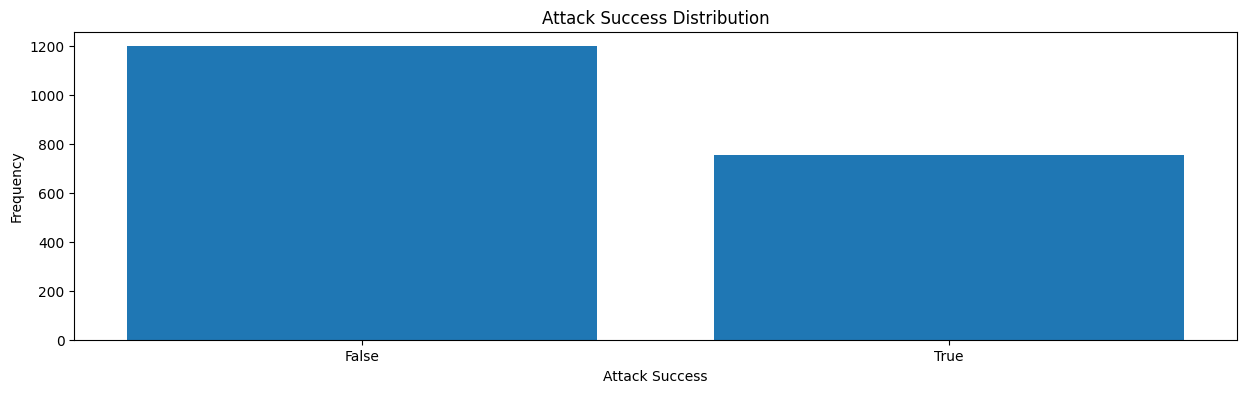

In [6]:
nums = df['kill'].value_counts()
fig, ax = plt.subplots(figsize = (15,4))
ax.bar(nums.index.astype(str), nums.values)
ax.set_xlabel("Attack Success")
ax.set_ylabel("Frequency")
ax.set_title("Attack Success Distribution")
plt.show()

##3b. Configurations

In [7]:
experiments = [
    # 0: baseline
    {'objective': 'binary:logistic', 'max_depth': 4,
     'learning_rate': 0.1, 'n_estimators': 300, 'alpha': 1},
    # 1: smaller learning rate/more trees - better generalization
    {'objective': 'binary:logistic', 'max_depth': 4,
     'learning_rate': 0.05, 'n_estimators': 400, 'alpha': 1},
    # 2: larger learning rate/less trees - unstable learning
    {'objective': 'binary:logistic', 'max_depth': 3,
     'learning_rate': 0.2, 'n_estimators': 80, 'alpha': 1},
    # 3: smaller alpha/deeper - more flexible
    {'objective': 'binary:logistic', 'max_depth': 4,
     'learning_rate': 0.1, 'n_estimators': 300, 'alpha': 0.5},
    # 4: larger alpha - prevent overfitting
    {'objective': 'binary:logistic', 'max_depth': 5,
     'learning_rate': 0.1, 'n_estimators': 300, 'alpha': 5},
]

## 3c. Encoder

In [8]:
le = LabelEncoder()
le.fit(res_train)
res_train_enc = le.transform(res_train)
res_val_enc = le.transform(res_val)
res_test_enc = le.transform(res_test)

##3d. Performance

In [9]:
DETERMINISTIC_ARGS = dict(
    enable_categorical=True,
    random_state=256,
    tree_method="hist",        # for repoduce
    n_jobs=1,                   # for reproduce
    sampling_method="uniform"   # for reproduce
)

In [10]:
res_results = []
best_model = None
best_f1 = -1
print(f"Starting Grid Search on {len(experiments)} configurations...\n")
for i, conf in enumerate(experiments):
  model = XGBClassifier(**DETERMINISTIC_ARGS, **conf)
  model.fit(X_train_res, res_train_enc)
  y_pred = model.predict(X_val_res)
  acc = accuracy_score(res_val_enc, y_pred)
  f1 = f1_score(res_val_enc, y_pred, average = "macro")
  res = conf.copy()
  res['index'] = i
  res['accuracy'] = acc
  res['f1'] = f1
  res_results.append(res)
  print(f"Exp {i+1}:  LR = {conf['learning_rate']},  alpha = {conf['alpha']} ->  Val acc: {acc:.4f}, Val F1: {f1:.3f}")
  if f1 > best_f1:
    best_f1 = f1
    best_model = model

df_res_results = pd.DataFrame(res_results)
print("\n" + "="*40)
print(" Final Leaderboard by F1")
print("="*40)
# sort best to worst
print(df_res_results.sort_values(by="f1", ascending = False).to_string(index=False))



Starting Grid Search on 5 configurations...

Exp 1:  LR = 0.1,  alpha = 1 ->  Val acc: 0.5631, Val F1: 0.521
Exp 2:  LR = 0.05,  alpha = 1 ->  Val acc: 0.5734, Val F1: 0.524
Exp 3:  LR = 0.2,  alpha = 1 ->  Val acc: 0.5768, Val F1: 0.520
Exp 4:  LR = 0.1,  alpha = 0.5 ->  Val acc: 0.5904, Val F1: 0.553
Exp 5:  LR = 0.1,  alpha = 5 ->  Val acc: 0.5939, Val F1: 0.527

 Final Leaderboard by F1
      objective  max_depth  learning_rate  n_estimators  alpha  index  accuracy       f1
binary:logistic          4           0.10           300    0.5      3  0.590444 0.552808
binary:logistic          5           0.10           300    5.0      4  0.593857 0.527221
binary:logistic          4           0.05           400    1.0      1  0.573379 0.524431
binary:logistic          4           0.10           300    1.0      0  0.563140 0.520899
binary:logistic          3           0.20            80    1.0      2  0.576792 0.519723


The low alpha model performs the best with the highest accuracy(0.5904) and f1(0.5528), with the high alpha model following close behind.  The large learning rate model performs the worst with the lowest f1 score.

##3e. Performance on Test Set

###3e2. Importance Plots

#### Accuracy Gain

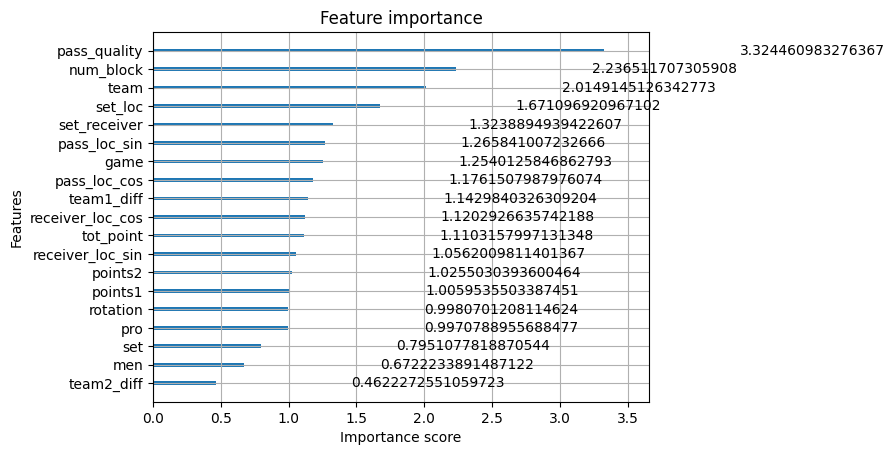

In [11]:
plot_importance(best_model, importance_type = 'gain')
plt.show()

Pass quality inproves accuracy the most followed by number of blocks and team then set_location.  The least important are gender, set number and level.  Many variables account for similar variability, so might investigate simpler model.

#### Weight Importance

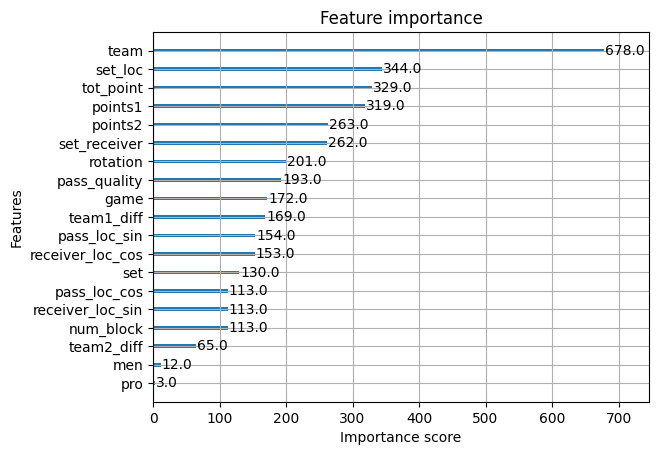

In [12]:
plot_importance(best_model, importance_type = 'weight')
plt.show()

The model uses team, set location, and the point features to split the most frequently as well as rotation and set_receiver.  On the other hand level, gender, and number of blocks are the least important.

#### Shap Values

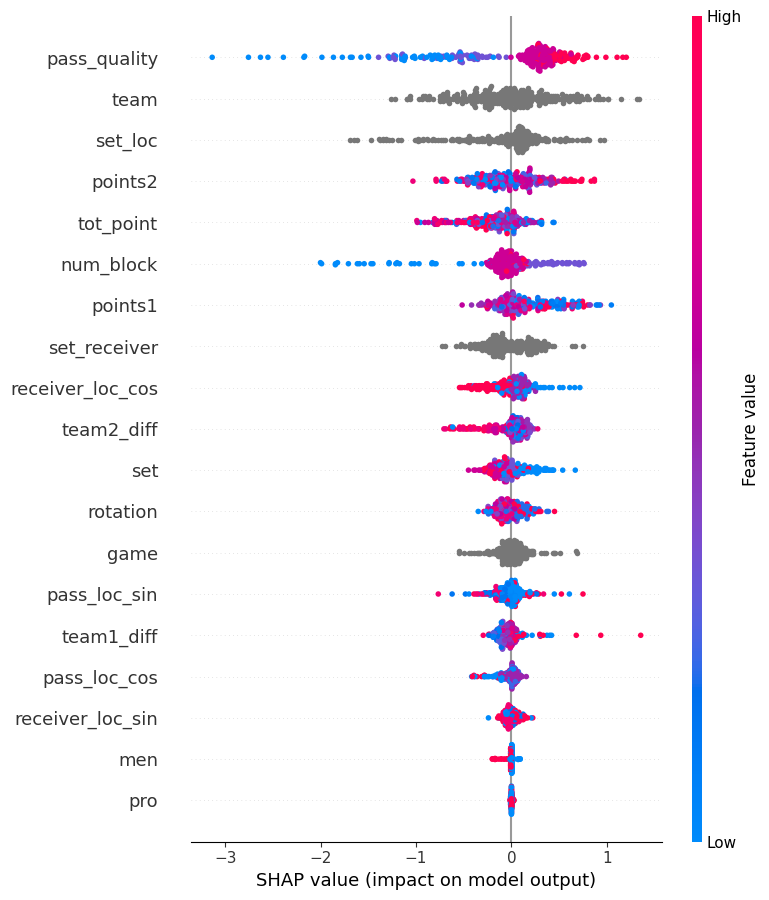

In [13]:
#del shap_values

explainer = shap.TreeExplainer(best_model)
sv = explainer.shap_values(X_test_res)
shap.summary_plot(sv, X_test_res)

The most important features to predicting attack result are pass_quality, team, set_loc, points, ans the number of blockers.  The least important features are level, gender, receiver net distance, and second touch lateral orientation.  Directionally, attack success is less likely when the pass quality is low.  Counterintuitively, an attack with few blocks is less likely to be a kill.  As the first touch moves from left to right, an attack is more likely to be successful.  As set increases, the likelihood an attack is a kill decreases.  When the setter is in the back row, the attack is more likely to be successful.  Men tend to have fewer kills.

### 3e3. Test Performance

In [14]:
y_pred = best_model.predict(X_test_res)
acc = accuracy_score(res_test_enc, y_pred)
f1 = f1_score(res_test_enc, y_pred, average = "binary")
print(f"Test accuracy: {acc}, Test F1 score: {f1}")
print("\nClassification Report")
print(classification_report(res_test_enc,
                            y_pred,
                            target_names = [str(c) for c in le.classes_]))

Test accuracy: 0.621160409556314, Test F1 score: 0.44221105527638194

Classification Report
              precision    recall  f1-score   support

       False       0.66      0.78      0.71       177
        True       0.53      0.38      0.44       116

    accuracy                           0.62       293
   macro avg       0.59      0.58      0.58       293
weighted avg       0.61      0.62      0.61       293



Lower scores for true category(difficulty predicting)

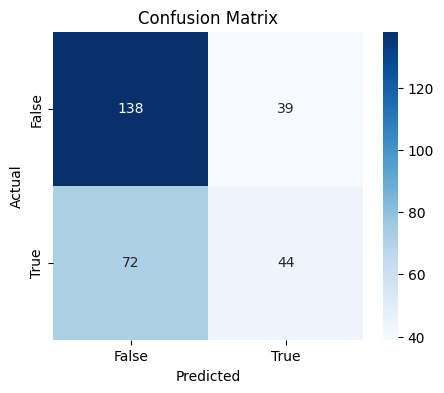

In [15]:
labels = le.classes_
plt.figure(figsize=(5,4))
cm = confusion_matrix(res_test_enc, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels = labels, yticklabels = labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Fairly low accuracy(not much better than guessing false everytime).  Predicts all categories, with more preds in correct categories.

Team and pass quality stay the most important features, and game increases in relevance.  Team 1 diff drops in relevance, but most ordering and direction stays relatively the same.

Global

Team drops in relevance, and gender increases in relevance.  Game also increases in relevance as well as second touch net distance.  

## 7c. Test Performance

Test accuracy: 0.621160409556314, Test F1 score: 0.44221105527638194

Classification Report
              precision    recall  f1-score   support

       False       0.66      0.78      0.71       177
        True       0.53      0.38      0.44       116

    accuracy                           0.62       293
   macro avg       0.59      0.58      0.58       293
weighted avg       0.61      0.62      0.61       293



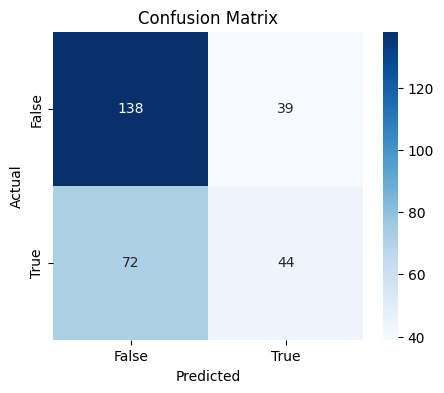

In [16]:
print(f"Test accuracy: {acc}, Test F1 score: {f1}")
print("\nClassification Report")
print(classification_report(res_test_enc,
                            y_pred,
                            target_names = [str(c) for c in le.classes_]))

labels = le.classes_
plt.figure(figsize=(5,4))
cm = confusion_matrix(res_test_enc, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels = labels, yticklabels = labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Only performs well predicting it is not a kill when it isnt.

Slight performance increase with information loss, but more prediction variability with predictions in all classes, so retain with fewer categories.

## 7d. Feature selection

In [17]:
feature_importance = pd.DataFrame({
    "feature": X_train_res.columns,
    "importance": np.abs(sv).mean(axis=0)
}).sort_values("importance", ascending=False)

print(feature_importance)

             feature  importance
8       pass_quality    0.573915
12              team    0.353552
9            set_loc    0.299690
1            points2    0.262534
4          tot_point    0.244441
10         num_block    0.241673
0            points1    0.235374
11      set_receiver    0.193098
13  receiver_loc_cos    0.151001
3         team2_diff    0.133538
5                set    0.130731
7           rotation    0.107475
6               game    0.104532
16      pass_loc_sin    0.097895
2         team1_diff    0.088461
15      pass_loc_cos    0.062240
14  receiver_loc_sin    0.051041
17               men    0.012327
18               pro    0.002502


1.   Using a 0.2 threshold, I will look at a model with pass_quality, team, set_loc, points2, tot_point, num_block, and points1.
2.   Based on columns, will investigate a the most relevant feature in group.  The chosen model includes pass_quality, rotation, team, set_loc, points2, pass_loc_sin.  The groups are first touch: [pass_quality, receiver_loc_cos, receiver_loc_sin], second touch:[pass_loc_sin, pass_loc_cos], third touch [set_loc, num_block, set_receiver] dem:[team, game, men, pro], game stage: [tot_pt, team1, team2, point1/2, set], rotation.





### 7d1. 0.05 Threshhold

#### Data

In [27]:
X_train_res = train_df[['pass_quality', 'team', 'set_loc', 'points2', 'tot_point', 'num_block', 'points1']]
X_val_res = val_df[['pass_quality', 'team', 'set_loc', 'points2', 'tot_point', 'num_block', 'points1']]
X_test_res = test_df[['pass_quality', 'team', 'set_loc', 'points2', 'tot_point', 'num_block', 'points1']]

####Model

In [19]:
res_results = []
best_model = None
best_f1 = -1
print(f"Starting Grid Search on {len(experiments)} configurations...\n")
for i, conf in enumerate(experiments):
  model = XGBClassifier(**DETERMINISTIC_ARGS, **conf)
  model.fit(X_train_res, res_train_enc)
  y_pred = model.predict(X_val_res)
  acc = accuracy_score(res_val_enc, y_pred)
  f1 = f1_score(res_val_enc, y_pred, average = "macro")
  res = conf.copy()
  res['index'] = i
  res['accuracy'] = acc
  res['f1'] = f1
  res_results.append(res)
  print(f"Exp {i+1}:  LR = {conf['learning_rate']},  alpha = {conf['alpha']} ->  Val acc: {acc:.4f}, Val F1: {f1:.3f}")
  if f1 > best_f1:
    best_f1 = f1
    best_model = model

df_loc_results = pd.DataFrame(res_results)
print("\n" + "="*40)
print(" Final Leaderboard by F1")
print("="*40)
# sort best to worst
print(df_res_results.sort_values(by="f1", ascending = False).to_string(index=False))

Starting Grid Search on 5 configurations...

Exp 1:  LR = 0.1,  alpha = 1 ->  Val acc: 0.5734, Val F1: 0.537
Exp 2:  LR = 0.05,  alpha = 1 ->  Val acc: 0.5768, Val F1: 0.540
Exp 3:  LR = 0.2,  alpha = 1 ->  Val acc: 0.5939, Val F1: 0.554
Exp 4:  LR = 0.1,  alpha = 0.5 ->  Val acc: 0.5973, Val F1: 0.566
Exp 5:  LR = 0.1,  alpha = 5 ->  Val acc: 0.5836, Val F1: 0.530

 Final Leaderboard by F1
      objective  max_depth  learning_rate  n_estimators  alpha  index  accuracy       f1
binary:logistic          4           0.10           300    0.5      3  0.590444 0.552808
binary:logistic          5           0.10           300    5.0      4  0.593857 0.527221
binary:logistic          4           0.05           400    1.0      1  0.573379 0.524431
binary:logistic          4           0.10           300    1.0      0  0.563140 0.520899
binary:logistic          3           0.20            80    1.0      2  0.576792 0.519723


Best model is the low alpha model with an accuracy of 0.5904 and an f1 score of 0.5528 followed by the high alpha model.  The model with fewer predictors performs identically, so retain simpler model.

#### Gain

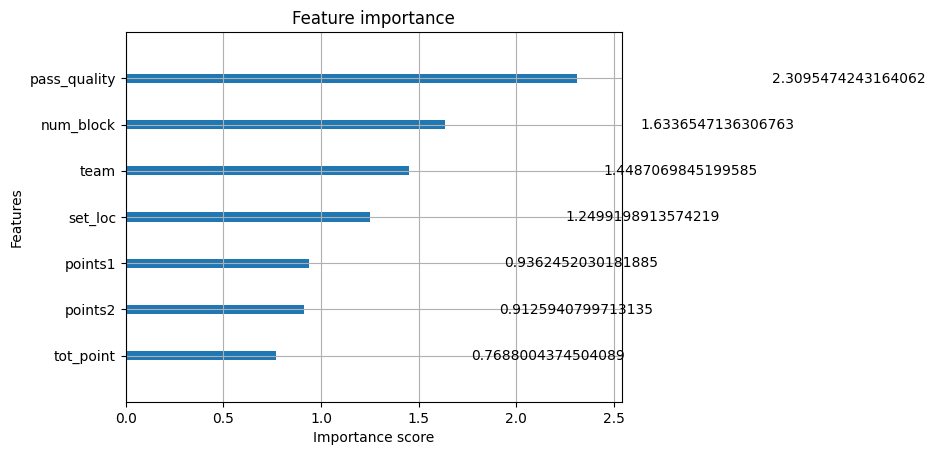

In [20]:
plot_importance(best_model, importance_type = 'gain')
plt.show()

Pass quality is the most important for accuracy gain followed by number of blockers, and team.  The least influential are the point variables.

#### Weight

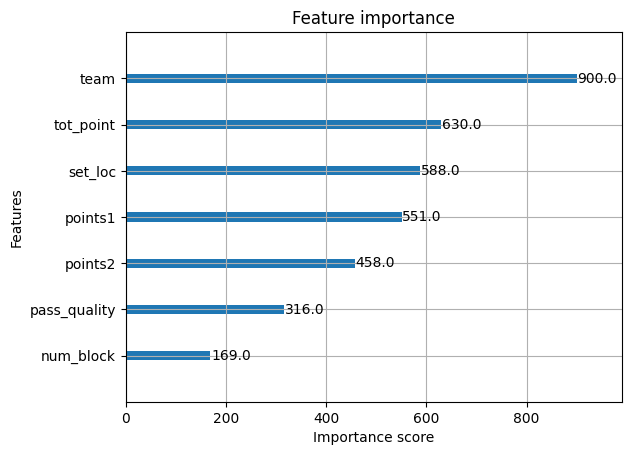

In [21]:
plot_importance(best_model, importance_type = 'weight')
plt.show()

The point variables increase in importance with total points being the second most important.  Team is the most important now.  Pass quality anf num block went from the top to the bottom.  Thus different features have different purposes.  

#### Shap

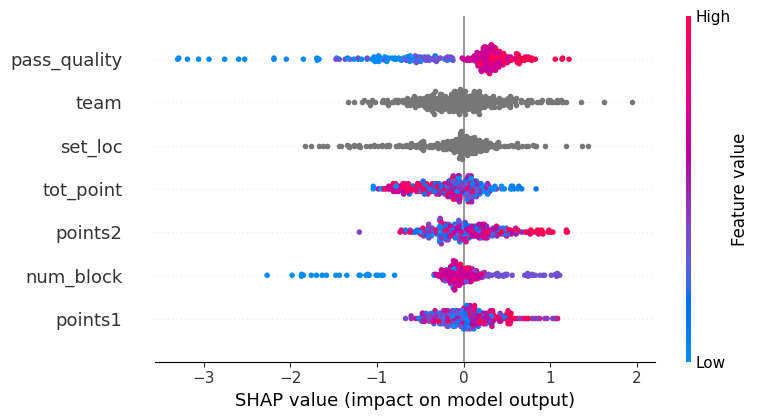

In [24]:
#del shap_values

explainer = shap.TreeExplainer(best_model)
sv = explainer.shap_values(X_test_res)
shap.summary_plot(sv, X_test_res)

The directional relationships remain the same.  With the same relevance except for tot point and point2 switch.

####Test performance

In [25]:
y_pred = best_model.predict(X_test_res)
acc = accuracy_score(res_test_enc, y_pred)
f1 = f1_score(res_test_enc, y_pred, average = "binary")
print(f"Test accuracy: {acc}, Test F1 score: {f1}")
print("\nClassification Report")
print(classification_report(res_test_enc,
                            y_pred,
                            target_names = [str(c) for c in le.classes_]))

Test accuracy: 0.6006825938566553, Test F1 score: 0.4236453201970443

Classification Report
              precision    recall  f1-score   support

       False       0.65      0.75      0.69       177
        True       0.49      0.37      0.42       116

    accuracy                           0.60       293
   macro avg       0.57      0.56      0.56       293
weighted avg       0.59      0.60      0.59       293



Decreased performance across all metrics.

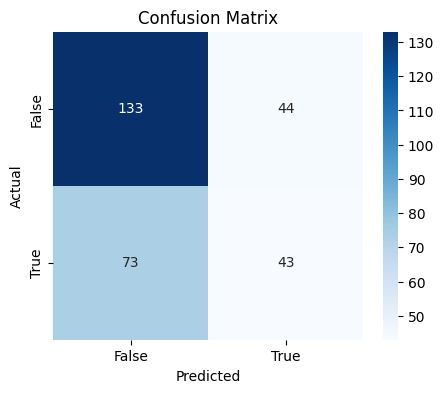

In [26]:
labels = le.classes_
plt.figure(figsize=(5,4))
cm = confusion_matrix(res_test_enc, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels = labels, yticklabels = labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Completely confused for the kill variables with half correct and half incorrect.  Slightly better with unsuccessful, but not much better.  

### 7d1. Group select

#### Data

In [28]:
X_train_res = train_df[['pass_quality', 'rotation', 'team', 'set_loc', 'points2']]
X_val_res = val_df[['pass_quality', 'rotation', 'team', 'set_loc', 'points2']]
X_test_res = test_df[['pass_quality', 'rotation', 'team', 'set_loc', 'points2']]

####Model

In [29]:
res_results = []
best_model = None
best_f1 = -1
print(f"Starting Grid Search on {len(experiments)} configurations...\n")
for i, conf in enumerate(experiments):
  model = XGBClassifier(**DETERMINISTIC_ARGS, **conf)
  model.fit(X_train_res, res_train_enc)
  y_pred = model.predict(X_val_res)
  acc = accuracy_score(res_val_enc, y_pred)
  f1 = f1_score(res_val_enc, y_pred, average = "macro")
  res = conf.copy()
  res['index'] = i
  res['accuracy'] = acc
  res['f1'] = f1
  res_results.append(res)
  print(f"Exp {i+1}:  LR = {conf['learning_rate']},  alpha = {conf['alpha']} ->  Val acc: {acc:.4f}, Val F1: {f1:.3f}")
  if f1 > best_f1:
    best_f1 = f1
    best_model = model

df_loc_results = pd.DataFrame(res_results)
print("\n" + "="*40)
print(" Final Leaderboard by F1")
print("="*40)
# sort best to worst
print(df_res_results.sort_values(by="f1", ascending = False).to_string(index=False))

Starting Grid Search on 5 configurations...

Exp 1:  LR = 0.1,  alpha = 1 ->  Val acc: 0.5427, Val F1: 0.514
Exp 2:  LR = 0.05,  alpha = 1 ->  Val acc: 0.5597, Val F1: 0.528
Exp 3:  LR = 0.2,  alpha = 1 ->  Val acc: 0.5529, Val F1: 0.521
Exp 4:  LR = 0.1,  alpha = 0.5 ->  Val acc: 0.5495, Val F1: 0.526
Exp 5:  LR = 0.1,  alpha = 5 ->  Val acc: 0.5802, Val F1: 0.520

 Final Leaderboard by F1
      objective  max_depth  learning_rate  n_estimators  alpha  index  accuracy       f1
binary:logistic          4           0.10           300    0.5      3  0.590444 0.552808
binary:logistic          5           0.10           300    5.0      4  0.593857 0.527221
binary:logistic          4           0.05           400    1.0      1  0.573379 0.524431
binary:logistic          4           0.10           300    1.0      0  0.563140 0.520899
binary:logistic          3           0.20            80    1.0      2  0.576792 0.519723


The low alpha model performs the same, so retain the simplest model.

####Performance

Gain

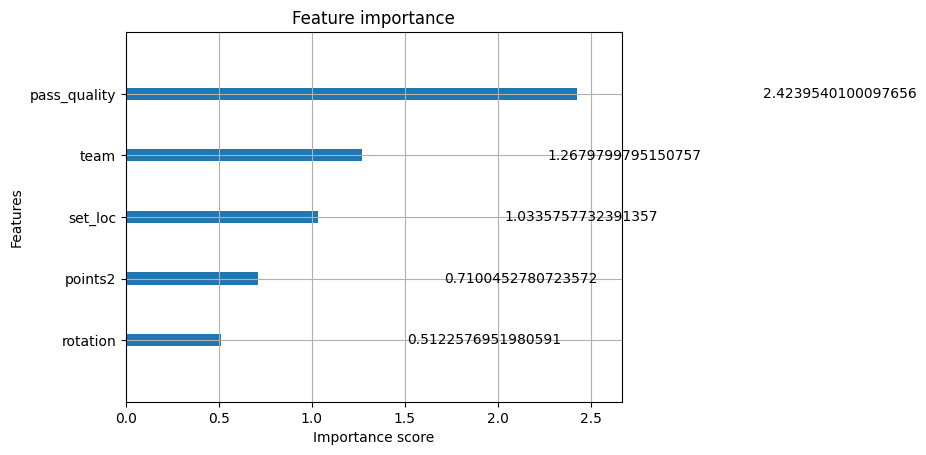

In [30]:
plot_importance(best_model, importance_type = 'gain')
plt.show()

Set up is the most important followed by dem then attack location.  The least important variables are location and points.

Weight

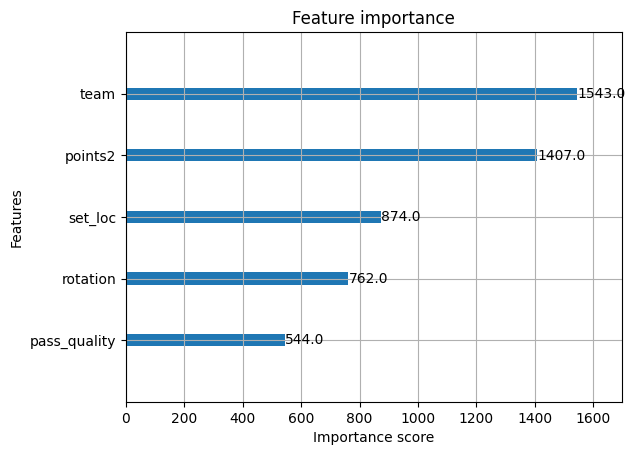

In [31]:
plot_importance(best_model, importance_type = 'weight')
plt.show()

Team becomes the most important follwed by points 2 then set loc and lastly rotation and pass quality.  Changed order.

Shap

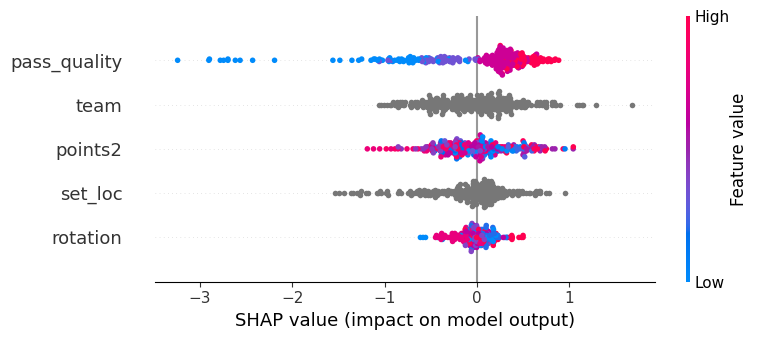

In [32]:
explainer = shap.TreeExplainer(best_model)
sv = explainer.shap_values(X_test_res)
shap.summary_plot(sv, X_test_res)

Same importance and relationships, but set loc drops below points 2.  